<a href="https://colab.research.google.com/github/ghadeer4705/AE_MegaProject_Group1/blob/main/Final_Dataset_MP_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import shutil
import zipfile
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image,ImageDraw,ImageFont,ImageFilter,ImageEnhance
from google.colab import files,drive
drive.mount('/content/drive')
zip_path='/content/drive/MyDrive/street_backgrounds.zip'
bg_folder='/content/street_backgrounds'

if os.path.exists(bg_folder):
    shutil.rmtree(bg_folder)

os.makedirs(bg_folder,exist_ok=True)
with zipfile.ZipFile(zip_path,'r') as zip_ref:
    zip_ref.extractall(bg_folder)

opFile="odlc_dataset_real"
os.makedirs(opFile,exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
Shapes=['circle','semicircle','quarter_circle','rectangle','triangle','pentagon','star','cross']
Colors={
    'white':(255,255,255),
    'black':(0,0,0),
    'red':(220,20,60),
    'blue':(0,102,204),
    'green':(34,139,34),
    'purple':(128,0,128),
    'brown':(139,69,19),
    'orange':(255,140,0)
}
Characters=[chr(i) for i in range(65,91)]+[str(i) for i in range(10)]
nSamples=3000
image_size=640

In [ ]:
def make_dSet_balanced(items,length):
    listt=(items*(length // len(items)+1))[:length]
    random.shuffle(listt)
    return listt

balanced_shapes=make_dSet_balanced(Shapes,nSamples)
balanced_shape_colors=make_dSet_balanced(list(Colors.keys()),nSamples)
balanced_chars=make_dSet_balanced(Characters,nSamples)
color_names=list(Colors.keys())

In [ ]:
def draw_shape(draw,shape_type,color,bbox):
    x0,y0,x1,y1=bbox
    w,h=x1-x0,y1-y0

    if shape_type == 'rectangle':
        draw.rectangle(bbox,fill=color)
    elif shape_type == 'circle':
        draw.ellipse(bbox,fill=color)
    elif shape_type == 'semicircle':
        draw.chord(bbox,start=0,end=180,fill=color)
    elif shape_type == 'quarter_circle':
        draw.pieslice(bbox,start=0,end=90,fill=color)
    elif shape_type == 'triangle':
        draw.polygon([(x0+w/2,y0),(x0,y1),(x1,y1)],fill=color)
    elif shape_type == 'pentagon':
        draw.polygon([(x0+w*0.5,y0),(x1,y0+h*0.4),(x0+w*0.8,y1),(x0+w*0.2,y1),(x0,y0+h*0.4)],fill=color)
    elif shape_type == 'star':
        points = [
            (x0+w*0.5,y0),(x0+w*0.65,y0+h*0.35),
            (x1,y0+h*0.35),(x0+w*0.75,y0+h*0.6),
            (x0+w*0.85,y1),(x0+w*0.5,y0+h*0.75),
            (x0+w*0.15,y1),(x0+w*0.25,y0+h*0.6),
            (x0,y0+h*0.35),(x0+w*0.35,y0+h*0.35)
        ]
        draw.polygon(points,fill=color)
    elif shape_type == 'cross':
        pad_w,pad_h=(w*0.3,h*0.3)
        draw.rectangle([x0+pad_w,y0,x1-pad_w,y1],fill=color)
        draw.rectangle([x0,y0+pad_h,x1,y1-pad_h],fill=color)

In [ ]:
try:
    font=ImageFont.truetype("LiberationSans-Bold.ttf",35)
except OSError:
    try:
        font=ImageFont.truetype("DejaVuSans-Bold.ttf",35)
    except OSError:
        font=ImageFont.load_default(size=35)
bg_files=[]
for root, _,files_list in os.walk(bg_folder):
    for f in files_list:
        if f.lower().endswith(('.png','.jpg','.jpeg')):
            bg_files.append(os.path.join(root,f))

In [ ]:
#Image Generation
dataset=[]

for i in range(nSamples):
    shape_name=balanced_shapes[i]
    shape_color_name=balanced_shape_colors[i]
    char=balanced_chars[i]
    text_color_name=random.choice([c for c in color_names if c != shape_color_name])

    bg_path=random.choice(bg_files)
    img=Image.open(bg_path).convert('RGB').resize((image_size,image_size))
    draw=ImageDraw.Draw(img)

    target_w=random.randint(50,80)
    target_h=target_w

    x0=random.randint(10,image_size-target_w-10)
    y0=random.randint(10,image_size-target_h-10)
    x1=x0+target_w
    y1=y0+target_h

    draw_shape(draw,shape_name,Colors[shape_color_name],[x0,y0,x1,y1])

    try:
        font=ImageFont.truetype("LiberationSans-Bold.ttf",22 if shape_name in ['semicircle','quarter_circle'] else 28)
    except OSError:
        font=ImageFont.load_default()

    text_bbox=draw.textbbox((0,0),char,font=font)
    text_w=text_bbox[2]-text_bbox[0]
    text_h=text_bbox[3]-text_bbox[1]

    text_x=x0+(target_w - text_w) / 2.0-text_bbox[0]
    text_y=y0+(target_h - text_h) / 2.0-text_bbox[1]

    if shape_name == 'semicircle':
        text_y += target_h*0.20
    elif shape_name == 'quarter_circle':
        text_x += target_w*0.15
        text_y += target_h*0.15
    elif shape_name == 'triangle':
        text_y += target_h*0.08

    draw.text((text_x, text_y),char,fill=Colors[text_color_name],font=font)

    filepath=os.path.join(opFile,f"sample_{i+1:04d}.png")
    img.save(filepath)

    x_center=(x0+x1)/2.0/image_size
    y_center=(y0+y1)/2.0/image_size
    norm_w=target_w/image_size
    norm_h=target_h/image_size

    full_label_class=f"{shape_name}/{shape_color_name}/{char}/{text_color_name}"

    dataset.append({
        'Image_Path':filepath,
        'Class_Name':full_label_class,
        'Shape':shape_name,
        'Character':char,
        'bbox':[x_center,y_center,norm_w,norm_h]
    })

df=pd.DataFrame(dataset)
print("Done.")

Done.


In [ ]:

yolo_dir="yolo_dataset_real"
shutil.rmtree(yolo_dir,ignore_errors=True)

for split in ['train','val','test']:
    os.makedirs(f"{yolo_dir}/images/{split}",exist_ok=True)
    os.makedirs(f"{yolo_dir}/labels/{split}",exist_ok=True)

from sklearn.model_selection import train_test_split
#Data Splitting:
train_df,temp_df=train_test_split(df,train_size=2000,stratify=df['Shape'],random_state=42)
val_df,test_df=train_test_split(temp_df,train_size=500,test_size=500,stratify=temp_df['Shape'],random_state=42)

def process_yolo_split(data_frame,split_name):
    for _,row in data_frame.iterrows():
        img_path=row['Image_Path']
        img_filename=os.path.basename(img_path)
        txt_filename=os.path.splitext(img_filename)[0]+".txt"

        dest_img_path=os.path.join(yolo_dir,'images',split_name,img_filename)
        shutil.copy(img_path,dest_img_path)

        class_id=0
        label_path=os.path.join(yolo_dir,'labels',split_name,txt_filename)

        x_center,y_center,width,height=row['bbox']

        with open(label_path,'w') as f:
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

process_yolo_split(train_df,'train')
process_yolo_split(val_df,'val')
process_yolo_split(test_df,'test')

yaml_content={
    'path':os.path.abspath(yolo_dir),
    'train':'images/train',
    'val':'images/val',
    'test':'images/test',
    'names':{0:'target'}
}

with open(f"{yolo_dir}/data.yaml",'w') as f:
    yaml.dump(yaml_content,f,default_flow_style=False)
shutil.make_archive('yolo_dataset_real','zip',yolo_dir)
files.download('yolo_dataset_real.zip')
print("Done.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.


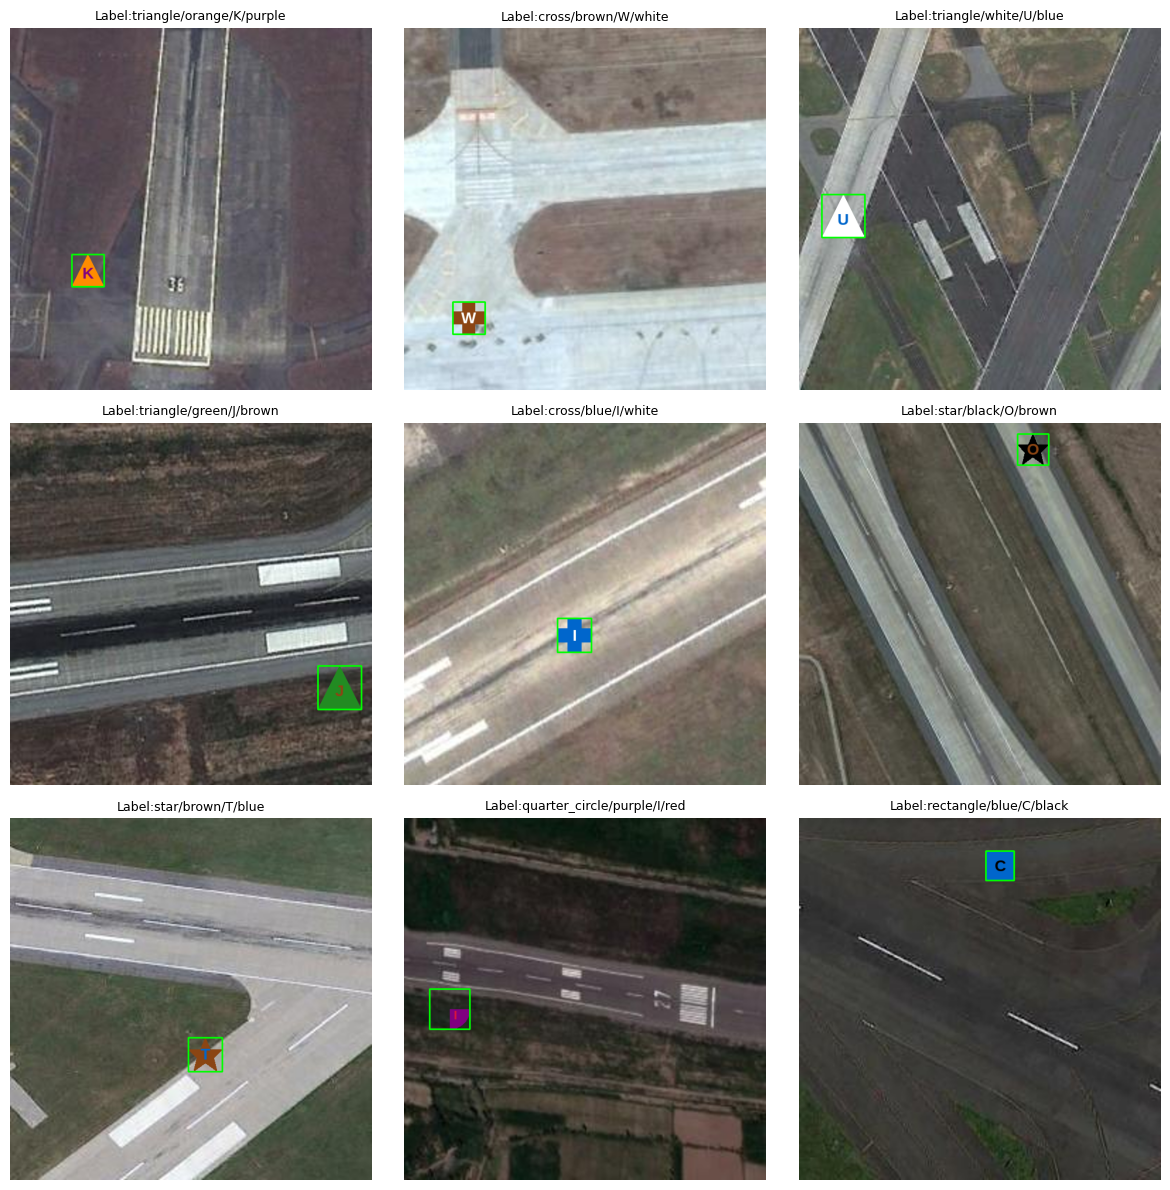

In [ ]:
import cv2
import matplotlib.pyplot as plt

sample_df=df.sample(9,random_state=42).reset_index(drop=True)

plt.figure(figsize=(12,12))

for i,row in sample_df.iterrows():
    img_path=row['Image_Path']
    img=cv2.imread(img_path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    x_c,y_c,w,h=row['bbox']

    img_h,img_w,_=img.shape
    x1=int((x_c-w/2)*img_w)
    y1=int((y_c-h/2)*img_h)
    x2=int((x_c+w/2)*img_w)
    y2=int((y_c+h/2)*img_h)

    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(f"Label:{row['Class_Name']}",fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()